# Ética, sesgos y privacidad

Este notebook desarrolla en detalle, con código y cifras, los hallazgos que
`README.md` resume en su sección 7. Se organiza en 5 bloques: sesgo de
muestreo, sesgo de procesamiento, sesgo de clase en el target, privacidad, y
una ficha de dataset (datasheet) completa.

No depende del catálogo de Kedro: todas las rutas son relativas desde
`notebooks/` hacia `data/`, para poder correrlo con un Jupyter estándar.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RUTA_CSV_CRUDO = Path("../data/01_raw/detecciones_waymo_like.csv")
RUTA_LIMPIO = Path("../data/02_intermediate/detecciones_limpias.parquet")
RUTA_WAYMO_TARGET = Path("../data/02_intermediate/waymo_con_target.parquet")

# Paleta categórica fija, la misma que en los notebooks 01 y 02.
AZUL = "#2a78d6"
AMARILLO = "#eda100"
VERDE = "#1baf7a"
ROJO = "#e34948"
SURFACE, INK_PRIMARY, INK_SECONDARY, GRID_COLOR, BASELINE = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7",
)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY, "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.titleweight": "bold",
})


def style_ax(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax

## Bloque 1 — Sesgo de muestreo

El sesgo de muestreo ocurre cuando la forma en que se recolectaron los datos
no representa proporcionalmente a la población sobre la que el sistema
después va a operar. No es un error de cálculo ni un problema que se
resuelva limpiando filas: es una propiedad de qué se decidió grabar, dónde y
cuándo, antes de que el dataset llegara a nuestras manos.

Para Waymo, la pregunta es directa: ¿los 798 segmentos de entrenamiento
cubren razonablemente las condiciones en las que un vehículo autónomo va a
manejar? Si la respuesta es no, cualquier modelo entrenado sobre esos datos
hereda ese sesgo, sin que ninguna técnica de modelamiento posterior pueda
corregirlo por completo.

In [2]:
censo = pd.DataFrame(
    {
        "condicion": ["clima"] * 2 + ["momento_del_dia"] * 3 + ["ubicacion"] * 3,
        "valor": ["sunny", "rain", "Day", "Night", "Dawn/Dusk", "San Francisco", "Phoenix", "location_other"],
        "n_segmentos": [793, 5, 647, 79, 72, 409, 284, 105],
    }
)
censo["pct"] = censo.groupby("condicion")["n_segmentos"].transform(lambda s: s / s.sum() * 100)
censo

,condicion,valor,n_segmentos,pct
0,clima,sunny,793,99.373434
1,clima,rain,5,0.626566
2,momento_del_dia,Day,647,81.077694
3,momento_del_dia,Night,79,9.899749
4,momento_del_dia,Dawn/Dusk,72,9.022556
5,ubicacion,San Francisco,409,51.253133
6,ubicacion,Phoenix,284,35.588972
7,ubicacion,location_other,105,13.157895


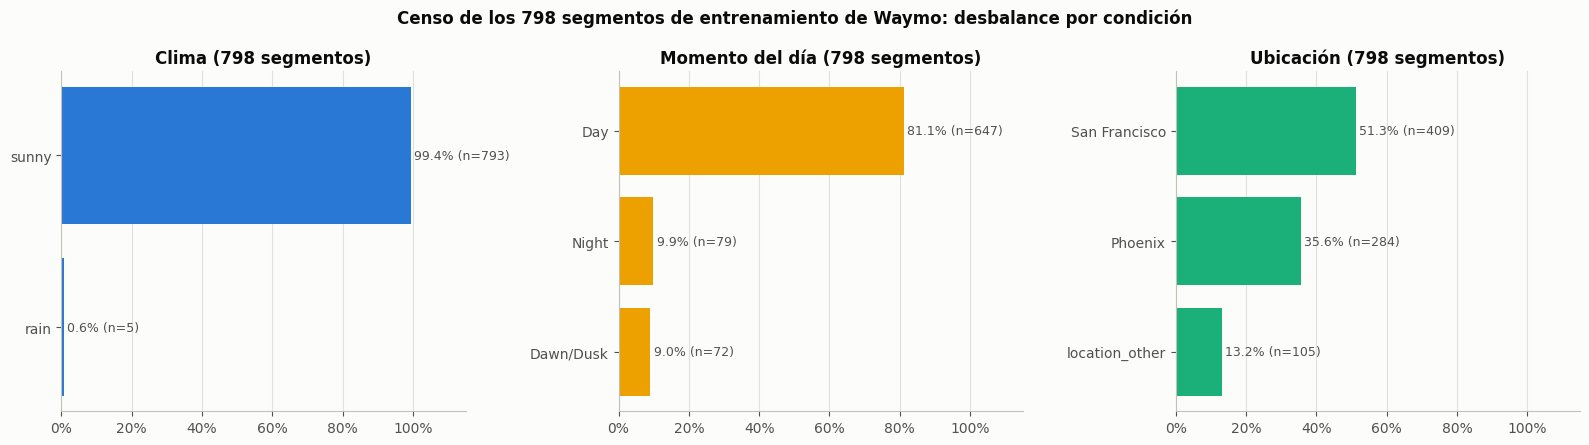

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colores = {"clima": AZUL, "momento_del_dia": AMARILLO, "ubicacion": VERDE}
titulos = {
    "clima": "Clima (798 segmentos)",
    "momento_del_dia": "Momento del día (798 segmentos)",
    "ubicacion": "Ubicación (798 segmentos)",
}

for ax, condicion in zip(axes, ["clima", "momento_del_dia", "ubicacion"]):
    datos = censo[censo["condicion"] == condicion].sort_values("pct")
    barras = ax.barh(datos["valor"], datos["pct"], color=colores[condicion])
    for barra, pct, n in zip(barras, datos["pct"], datos["n_segmentos"]):
        ax.text(barra.get_width() + 1, barra.get_y() + barra.get_height() / 2,
                f"{pct:.1f}% (n={n})", va="center", fontsize=9, color=INK_SECONDARY)
    ax.set_xlim(0, 115)
    ax.set_title(titulos[condicion])
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    style_ax(ax)

fig.suptitle("Censo de los 798 segmentos de entrenamiento de Waymo: desbalance por condición", fontweight="bold")
fig.tight_layout()
plt.show()

### TODO respondido

**Un vehículo autónomo entrenado con estos datos ha visto llover 5 veces
sobre 798 segmentos totales (0,6%).** De noche, la cifra sube a 79 de 798
(9,9%), y fuera de San Francisco, Phoenix o "location_other" (una categoría
agregada, no una cuarta ciudad), la cifra es 0 de 798 (0%): ninguna de las
tres ubicaciones documentadas está fuera de Estados Unidos.

**¿Qué pasa cuando ese sistema se despliega en Santiago en junio?** Junio en
Santiago es invierno: hay lluvia, niebla matinal frecuente y amanecer
después de las 7:00 AM, condiciones que en el censo de entrenamiento
representan un cruce casi inexistente (rain, con solo 5 segmentos en total,
y ninguno documentado como Dawn/Dusk con lluvia). El modelo tendría que
generalizar a partir de prácticamente cero ejemplos de esa combinación
específica. Además, la señalización, el trazado de calles y el
comportamiento de otros conductores en Santiago no están representados en
absoluto: el modelo nunca vio una calle chilena. El riesgo no es solo una
caída de métrica, es operar con una confianza que los datos de
entrenamiento no respaldan.

**¿Es esto un error de Waymo?** No en el sentido de una falla técnica: Waymo
documenta abiertamente el alcance geográfico y de condiciones de su dataset,
y la flota efectivamente opera en las ciudades de EE.UU. donde fue grabada.
El dataset cumple el propósito para el que Waymo lo recolectó. El error
aparecería recién si alguien (nosotros, en este proyecto, o cualquier otro
equipo) usara este dataset para entrenar o validar un sistema pensado para
desplegarse en un contexto que el dataset no cubre, sin decirlo
explícitamente ni validar con datos locales. La responsabilidad de esa
decisión es de quien reutiliza el dataset fuera de su alcance documentado,
no de quien lo publicó con ese alcance declarado.

## Bloque 2 — Sesgo de procesamiento

El sesgo de procesamiento aparece durante la limpieza de los datos, no en su
recolección: una decisión de filtrado que parece neutral (por ejemplo,
"eliminar valores atípicos") puede en la práctica eliminar de forma
desproporcionada a un subgrupo real, si ese subgrupo tiende a producir
valores que el criterio estadístico marca como atípicos. La sección 5 de
`01_exploracion_csv.ipynb` ya identificó un caso concreto: los buses y
camiones (`box_length` > 10 m) son estadísticamente atípicos dentro de
`VEHICLE`, pero son una clase real, no un error de captura.

In [4]:
crudo = pd.read_csv(RUTA_CSV_CRUDO)
limpio = pd.read_parquet(RUTA_LIMPIO)

# Para comparar peras con peras normalizamos solo las etiquetas de
# object_type del crudo (Ped/Pedestrian/PEATON -> PEDESTRIAN), sin aplicar
# el resto de la limpieza (nulos, duplicados, valores imposibles). Así el
# "antes" tiene las mismas 4 clases que el "después" y la comparación mide
# el efecto de la limpieza, no el de unificar etiquetas.
OBJECT_TYPE_MAP = {"PED": "PEDESTRIAN", "PEATON": "PEDESTRIAN"}
object_type_antes = crudo["object_type"].str.strip().str.upper().replace(OBJECT_TYPE_MAP)

ORDEN = ["VEHICLE", "PEDESTRIAN", "SIGN", "CYCLIST"]


def _composicion(serie, n_filas):
    pct = serie.value_counts(normalize=True) * 100
    fila = {"n_filas": n_filas}
    for tipo in ORDEN:
        fila[f"%_{tipo}"] = round(pct.get(tipo, 0.0), 2)
    return fila


comparacion = pd.DataFrame(
    [_composicion(object_type_antes, len(crudo)), _composicion(limpio["object_type"], len(limpio))],
    index=["antes (crudo, solo etiquetas normalizadas)", "después (limpio)"],
)
comparacion

,n_filas,%_VEHICLE,%_PEDESTRIAN,%_SIGN,%_CYCLIST
"antes (crudo, solo etiquetas normalizadas)",40680,61.73,28.21,8.12,1.94
después (limpio),39800,61.75,28.20,8.10,1.95


In [5]:
# Cifra puntual citada en la ficha del dataset (Bloque 5): conteo crudo de
# CYCLIST en el dataset limpio, no solo el porcentaje.
n_cyclist_limpio = int((limpio["object_type"] == "CYCLIST").sum())
print(f"CYCLIST en el sintetico limpio: {n_cyclist_limpio} de {len(limpio):,} "
      f"({n_cyclist_limpio / len(limpio):.2%})")

CYCLIST en el sintetico limpio: 776 de 39,800 (1.95%)


La composición por clase es prácticamente idéntica antes y después de la
limpieza (todas las clases se mueven menos de 0,1 puntos porcentuales): la
limpieza no perjudicó a ningún grupo de forma desproporcionada. Esto no es
automático, es el resultado directo de haber evitado el filtro por IQR sobre
`box_length` que se analiza en la siguiente celda.

In [6]:
# El argumento de defensa más importante del proyecto: que habría pasado si
# se hubiera aplicado un filtro estadístico estándar sobre box_length.
buses = limpio[limpio["box_length"] > 10]
n_buses = len(buses)
pct_buses = n_buses / len(limpio) * 100

print(f"Filas con box_length > 10 m en el dataset limpio: {n_buses} ({pct_buses:.2f}% del total)")
print(f"Todas son de tipo: {buses['object_type'].unique()}")
print()
print("Dimensiones de esas filas (ancho y alto), para confirmar que son buses reales y no ruido:")
print(buses[["box_length", "box_width", "box_height"]].describe().loc[["mean", "min", "max"]].round(2))
print()
print("Para comparar, dimensiones de un VEHICLE 'normal' (box_length <= 10 m):")
autos = limpio[(limpio["object_type"] == "VEHICLE") & (limpio["box_length"] <= 10)]
print(autos[["box_length", "box_width", "box_height"]].describe().loc[["mean", "min", "max"]].round(2))

Filas con box_length > 10 m en el dataset limpio: 597 (1.50% del total)
Todas son de tipo: ['VEHICLE']

Dimensiones de esas filas (ancho y alto), para confirmar que son buses reales y no ruido:
      box_length  box_width  box_height
mean       15.14       2.65        3.27
min        12.01       2.40        2.90
max        18.00       2.90        3.60

Para comparar, dimensiones de un VEHICLE 'normal' (box_length <= 10 m):
      box_length  box_width  box_height
mean        4.60       1.90        1.60
min         1.88       1.14        0.63
max         7.42       2.80        2.55


### TODO respondido

**¿Qué habría pasado si se hubieran eliminado los outliers de `box_length`
con el criterio IQR?** La sección 5 de `01_exploracion_csv.ipynb` ya calculó
que el criterio IQR marca 804 filas de `VEHICLE` como atípicas (3,2% de esa
clase), de las cuales 597 sobreviven en el dataset limpio actual como buses
y camiones reales (ancho y alto muy por sobre el promedio de un auto, ver
celda anterior). Aplicar el filtro IQR las habría eliminado por completo:
el dataset final habría quedado sin un solo ejemplo de vehículo de gran
tamaño.

**¿Sobre qué grupo recaería la consecuencia y por qué importa en conducción
autónoma?** Recaería sobre la subclase de vehículos grandes dentro de
`VEHICLE`, que además de ser menos frecuente en el dataset (1,5% del total)
es la que representa mayor riesgo físico si el sistema falla en detectarla:
un bus o un camión tiene mucha más masa y un radio de giro distinto al de un
auto, así que un error de detección o de clasificación de tamaño sobre ese
subgrupo tiene consecuencias de seguridad más severas que el mismo error
sobre un auto pequeño. Eliminar esa subclase del entrenamiento no la hace
desaparecer del mundo real: solo hace que el modelo nunca haya visto un
ejemplo de ella.

**¿Por qué la métrica de accuracy promedio no mostraría este problema?**
Porque incluso sin un solo bus en el dataset de entrenamiento, el accuracy
global de un modelo de detección de objetos apenas se movería: los buses
son el 1,5% de las filas, así que un modelo que los clasifica
sistemáticamente mal (o que ni siquiera los detecta como una geometría
válida) seguiría acertando en el 98,5% restante. El promedio general
esconde por diseño el error concentrado en un subgrupo minoritario; hace
falta una métrica desagregada por subgrupo (por ejemplo, recall específico
sobre `VEHICLE` con `box_length` > 10 m) para que el problema sea visible.

## Bloque 3 — Sesgo de clase en el target

`tiene_camara`, el target binario de este proyecto, también está
desbalanceado: no todas las detecciones LiDAR tienen la misma probabilidad
de estar confirmadas por cámara, y esa probabilidad no es aleatoria, está
asociada al clima. Esto es distinto a los sesgos de las secciones 1 y 2: no
es un problema de qué se recolectó ni de cómo se limpió, es una propiedad
del fenómeno que el modelo tiene que predecir.

In [7]:
waymo = pd.read_parquet(RUTA_WAYMO_TARGET)

# Composición por tipo de objeto en los datos reales, para respaldar con un
# cálculo dentro del propio notebook la cifra de CYCLIST que se cita en la
# ficha del dataset (Bloque 5): tiene que coincidir con lo que arme acá.
TYPE_MAP = {1: "VEHICLE", 2: "PEDESTRIAN", 3: "SIGN", 4: "CYCLIST"}
tipo_counts = waymo["[LiDARBoxComponent].type"].map(TYPE_MAP).value_counts()
tipo_pct = (tipo_counts / len(waymo) * 100).round(2)

print("Composición de object_type en waymo_con_target:")
print(pd.DataFrame({"n": tipo_counts, "%": tipo_pct}))

n_cyclist = int(tipo_counts["CYCLIST"])
print(f"\nCYCLIST: {n_cyclist} de {len(waymo):,} ({n_cyclist / len(waymo):.2%})")

Composición de object_type en waymo_con_target:
                              n      %
[LiDARBoxComponent].type              
VEHICLE                   16083  47.17
SIGN                      10368  30.41
PEDESTRIAN                 7300  21.41
CYCLIST                     347   1.02

CYCLIST: 347 de 34,098 (1.02%)


In [8]:
balance_global = waymo["tiene_camara"].value_counts(normalize=True) * 100
print("Balance global de tiene_camara:")
print(balance_global.round(1))

Balance global de tiene_camara:
tiene_camara
0    84.3
1    15.7
Name: proportion, dtype: float64


In [9]:
balance_segmento = (
    waymo.groupby(["segment_id", "weather", "time_of_day", "location"])["tiene_camara"]
    .agg(n_detecciones="size", n_positivos="sum")
    .reset_index()
)
balance_segmento["pct_positivos"] = balance_segmento["n_positivos"] / balance_segmento["n_detecciones"] * 100
balance_segmento.sort_values("pct_positivos", ascending=False)

,segment_id,weather,time_of_day,location,n_detecciones,n_positivos,pct_positivos
0,10023947602400723454_1120_000_1140_000,sunny,Day,location_sf,18633,4922,26.415499
1,10206293520369375008_2796_800_2816_800,sunny,Night,location_phx,2871,153,5.329154
2,11017034898130016754_697_830_717_830,sunny,Dawn/Dusk,location_other,5757,191,3.317700
3,6791933003490312185_2607_000_2627_000,rain,Dawn/Dusk,location_phx,6837,86,1.257862


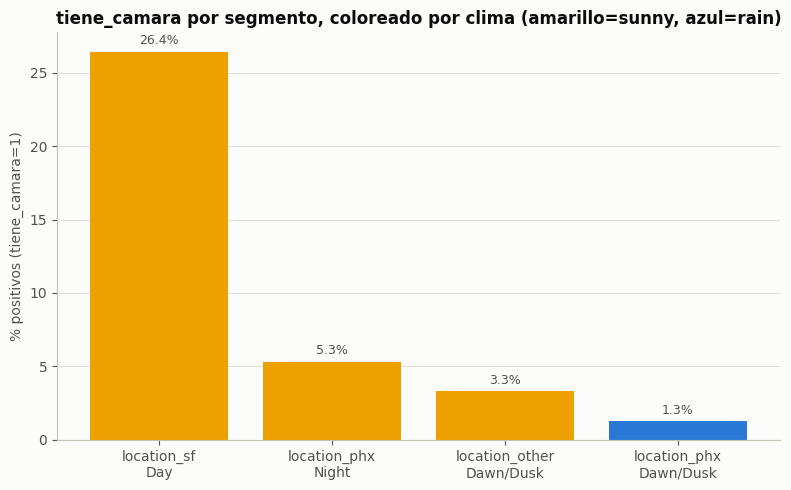

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
colores_clima = {"sunny": AMARILLO, "rain": AZUL}
etiquetas = balance_segmento["location"] + "\n" + balance_segmento["time_of_day"]
barras = ax.bar(
    etiquetas,
    balance_segmento["pct_positivos"],
    color=[colores_clima[w] for w in balance_segmento["weather"]],
)
for barra, pct in zip(barras, balance_segmento["pct_positivos"]):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.5,
            f"{pct:.1f}%", ha="center", fontsize=9, color=INK_SECONDARY)

ax.set_ylabel("% positivos (tiene_camara=1)")
ax.set_title("tiene_camara por segmento, coloreado por clima (amarillo=sunny, azul=rain)")
style_ax(ax, grid_axis="y")
fig.tight_layout()
plt.show()

In [11]:
pct_sunny_ponderado = waymo.loc[waymo["weather"] == "sunny", "tiene_camara"].mean() * 100
pct_rain_ponderado = waymo.loc[waymo["weather"] == "rain", "tiene_camara"].mean() * 100
razon = pct_sunny_ponderado / pct_rain_ponderado

print(f"% positivos en filas sunny (ponderado por detección, 3 segmentos): {pct_sunny_ponderado:.2f}%")
print(f"% positivos en filas rain (1 segmento): {pct_rain_ponderado:.2f}%")
print(f"La tasa de positivos en sunny es {razon:.1f} veces la de rain.")

% positivos en filas sunny (ponderado por detección, 3 segmentos): 19.32%
% positivos en filas rain (1 segmento): 1.26%
La tasa de positivos en sunny es 15.4 veces la de rain.


### TODO respondido

**¿Por qué el segmento con lluvia tiene solo 1,3% de positivos?** El target
`tiene_camara` depende de que la cámara también haya detectado el mismo
objeto que el LiDAR. La lluvia degrada específicamente la visibilidad de la
cámara (gotas sobre el lente, reflejos, menor contraste), mientras que el
LiDAR sigue midiendo distancia por tiempo de vuelo del láser, mucho menos
afectado por la lluvia moderada. El resultado físico esperado es exactamente
lo que se observa: el LiDAR sigue detectando objetos con normalidad, pero la
cámara deja de confirmarlos, así que `tiene_camara` cae. La tasa de
positivos ponderada por detección es 15,4 veces más alta en `sunny` que en
`rain` (19,3% contra 1,3%).

**¿Qué métrica usarías para evaluar el modelo y por qué no accuracy?**
Los KPIs de este proyecto (README, sección 3) son Recall ≥ 0,85 para la
clase positiva, F1 ≥ 0,80 y AUC-ROC ≥ 0,85, más una brecha de F1 entre
`sunny` y `rain` ≤ 10 puntos porcentuales. Con un target donde la clase
positiva es 15,7% del total, un modelo que siempre predice 0 ya tiene 84,3%
de accuracy sin haber aprendido nada: el accuracy no distingue entre un
modelo útil y uno que ignora la clase minoritaria. Recall mide
específicamente si el modelo encuentra los positivos reales, F1 evita que
maximizar recall se pague con demasiados falsos positivos, y la brecha por
clima es la métrica que existe específicamente para detectar el sesgo
descrito en este bloque, que un promedio global no vería.

**¿Qué técnica aplicarías en EP2 para compensar el desbalance?** Sobre el
desbalance de `tiene_camara` (15,7% positivos), `class_weight` balanceado o
SMOTE sobre el conjunto de entrenamiento, evaluando ambas opciones porque
SMOTE interpola vecinos en el espacio de atributos y puede generar ejemplos
sintéticos poco realistas si las clases están muy solapadas
geométricamente. Además, dado que la brecha real es por clima y no solo por
clase, conviene evaluar el modelo con una validación separada por segmento
(no solo un split aleatorio), para que el desempeño en `rain` no quede
promediado y escondido dentro del desempeño general en `sunny`.

## Bloque 4 — Privacidad

Reidentificación es el riesgo de que, aunque un dataset no tenga un campo de
"nombre" o "RUT", la combinación de varias columnas aparentemente inocuas
alcance para señalar a una persona o un objeto específico de forma única. En
este dataset no hay biometría ni identificadores directos, pero cada
detección lleva un identificador de objeto (`id_interno` /
`key.laser_object_id`) y una marca de tiempo: si esa combinación es única
fila por fila, en teoría alcanza para reconstruir la trayectoria completa de
un objeto (por ejemplo, un peatón) a lo largo de un segmento.

La Ley 21.719 de Chile (2024, que modifica la Ley 19.628 de protección de
datos personales) establece, entre otros, dos principios directamente
aplicables acá: **minimización**, que exige recolectar y conservar solo los
datos estrictamente necesarios para el fin declarado, y **finalidad**, que
exige que los datos solo se usen para el propósito para el que fueron
recolectados, no para cualquier uso posterior que se le ocurra a quien los
tiene. Un dataset de detecciones LiDAR no identifica personas por nombre,
pero si se usara para, por ejemplo, reconstruir el patrón de movimiento
diario de peatones en una calle específica, eso excedería la finalidad
original (evaluar un sistema de percepción) y violaría minimización si se
conservan columnas que no aportan a esa finalidad.

In [12]:
limpio = pd.read_parquet(RUTA_LIMPIO)
n = len(limpio)

combinaciones = [
    ["segment_id"],
    ["segment_id", "time_of_day"],
    ["segment_id", "timestamp_micros"],
    ["segment_id", "timestamp_micros", "object_type"],
    ["segment_id", "timestamp_micros", "id_interno"],
]

filas_resumen = []
for combo in combinaciones:
    grupos = limpio.groupby(combo, dropna=False).size()
    n_grupos = len(grupos)
    grupos_unicos = int((grupos == 1).sum())
    filas_resumen.append(
        {
            "combinacion": " + ".join(combo),
            "n_grupos": n_grupos,
            "grupos_de_1_fila": grupos_unicos,
            "%_unicos": round(grupos_unicos / n_grupos * 100, 2),
        }
    )

resumen_cardinalidad = pd.DataFrame(filas_resumen)
resumen_cardinalidad

,combinacion,n_grupos,grupos_de_1_fila,%_unicos
0,segment_id,153,0,0.00
1,segment_id + time_of_day,459,0,0.00
2,segment_id + timestamp_micros,22299,10879,48.79
3,segment_id + timestamp_micros + object_type,30153,22516,74.67
4,segment_id + timestamp_micros + id_interno,39800,39800,100.00


In [13]:
# Autochequeo: el identificador de una detección individual debe ser único
# dentro de segment_id + timestamp_micros + id_interno. Si esto fallara,
# significaría que hay colisiones de id_interno dentro del mismo instante,
# y el argumento de "no hay forma de reidentificar por esta vía" no se
# sostendría.
llave_completa = ["segment_id", "timestamp_micros", "id_interno"]
grupos_llave_completa = limpio.groupby(llave_completa, dropna=False).size()

assert (grupos_llave_completa == 1).all(), "Hay combinaciones de segment_id+timestamp_micros+id_interno repetidas"
print(f"OK: {len(grupos_llave_completa):,} combinaciones de {llave_completa}, 100% con exactamente 1 fila.")

OK: 39,800 combinaciones de ['segment_id', 'timestamp_micros', 'id_interno'], 100% con exactamente 1 fila.


### TODO respondido

**Un peatón detectado es una persona. ¿Qué se podría reconstruir cruzando
con otra fuente?** Dentro de este dataset, `id_interno` (o
`key.laser_object_id` en los datos reales) junto con `timestamp_micros`
permite reconstruir la trayectoria completa de un peatón específico dentro
de un segmento: posición en cada instante, velocidad, cuánto tiempo
permaneció en la escena. Solo con estas columnas no hay forma de saber
*quién* es esa persona. El riesgo aparece si se cruza con una fuente externa
que sí tenga identidad asociada a una posición y un momento (por ejemplo,
video de una cámara de seguridad de un local cercano con timestamp, o el
registro de acceso de un edificio en esa cuadra a esa hora): la trayectoria
LiDAR serviría como el "esqueleto" temporal-espacial que conecta esos dos
mundos.

**Aplicando minimización, ¿qué columna quitarías si el objetivo es solo
clasificar `tiene_camara`?** `key.laser_object_id` y
`key.frame_timestamp_micros` (o, en el CSV sintético, `id_interno` y
`timestamp_micros`): un clasificador de `tiene_camara` predice a partir de
los atributos geométricos y de sensor de una detección individual (tamaño,
velocidad, `num_lidar_points_in_box`, tipo de objeto, clima), no necesita
saber qué objeto específico ni en qué instante exacto fue detectado. Son
justamente las dos columnas identificadas arriba como la vía de
reidentificación, así que quitarlas del conjunto de atributos del modelo
reduce ese riesgo sin perder capacidad predictiva. `segment_id` se puede
conservar aparte, no como atributo del modelo sino como llave para separar
entrenamiento y validación por segmento (ver Bloque 3).

**¿Por qué la licencia de Waymo prohíbe redistribuir los datos?** Porque
Waymo recolectó datos en vía pública, con personas y vehículos reales
circulando, bajo condiciones de anonimización (rostros y patentes
difuminados en cámara) pensadas para su propio proceso de publicación
controlada, no para que terceros los redistribuyan sin control. Permitir
redistribución abierta debilitaría esas protecciones y la capacidad de
Waymo de hacer cumplir el principio de finalidad sobre cómo se usan los
datos. Por eso `data/01_raw/waymo/` está en `.gitignore` en este proyecto
(ver README, sección 7 y sección 9): es la forma concreta en que este
repositorio cumple la licencia sin dejar de ser reproducible, documentando
en el README cómo volver a descargar los mismos 4 segmentos en vez de
subirlos al repositorio.

## Bloque 5 — Ficha del dataset (Datasheet)

**Dataset:** Waymo Open Dataset v2 + CSV sintético · **Equipo:**
maicolhernandez / francismoya · **Fecha:** septiembre 2026

### Origen

| Campo | Waymo Open Dataset v2 (real) | CSV sintético |
|---|---|---|
| Quién lo recolectó | Waymo LLC | Docente del curso MLY1101 |
| Propósito original | Investigación en conducción autónoma | Evaluación académica del curso |
| Cómo se recolectó | Flota de vehículos autónomos equipados con sensores LiDAR y cámaras, en vías públicas | Generador sintético que replica el esquema `lidar_box`, con defectos de calidad inyectados a propósito |
| Periodo y lugar | 2019; San Francisco, Phoenix y Mountain View (agregado como "location_other"), EE.UU. | No aplica (generado, no capturado) |
| Licencia | No comercial, prohíbe redistribución | Uso académico del curso |

### Representatividad

Censo de los 798 segmentos de entrenamiento (Bloque 1): 793 `sunny` (99,4%)
y 5 `rain` (0,6%); 647 `Day` (81,1%), 79 `Night` (9,9%) y 72 `Dawn/Dusk`
(9,0%); 409 San Francisco (51,3%), 284 Phoenix (35,6%) y 105
`location_other` (13,2%). Los 4 segmentos de la muestra de este proyecto
(34.098 detecciones) se eligieron a propósito para maximizar contraste, no
para ser representativos: 3 de 4 son `sunny` y 1 es `rain`, una proporción
de lluvia (25%) más alta que la real (0,6%), pero de todas formas apenas
6.837 detecciones bajo lluvia contra 27.261 bajo sol en términos absolutos.

| Dimensión | Grupo subrepresentado | % en el dataset |
|---|---|---|
| Clase de objeto | `CYCLIST` | 1,02% en datos reales (347 de 34.098, calculado en el Bloque 3); 1,95% en sintético limpio (776 de 39.800, calculado en el Bloque 2) |
| Clima | `rain` | 5 de 798 segmentos de entrenamiento (0,6%) |
| Momento del día | `Night` | 79 de 798 segmentos (9,9%) |
| Ubicación | fuera de EE.UU. | 0 de 798 segmentos (0%) |

### Evaluación de impacto

- **Decisión técnica que empeoraría el sesgo:** eliminar los valores
  atípicos de `box_length` con el criterio estadístico IQR eliminaría los
  597 buses y camiones reales que hoy sobreviven en el dataset limpio
  (Bloque 2).
- **Consecuencia concreta:** el modelo no tendría ningún ejemplo de
  vehículo de gran tamaño durante el entrenamiento, justo la subclase con
  mayor masa y mayor riesgo físico en caso de una falla de detección.
- **Por qué accuracy no lo mostraría:** `CYCLIST` es apenas 1,0%-2,0% de
  los datos según la fuente; un modelo que siempre predice "no es
  ciclista" ya acierta en ese 98%-99% restante sin haber aprendido nada
  sobre la clase minoritaria, y lo mismo aplica a `tiene_camara` (84,3% de
  accuracy con un modelo que siempre predice 0).
- **Qué haremos:** `class_weight` balanceado o SMOTE para compensar el
  desbalance de `tiene_camara` y de `object_type`, evaluando ambas
  opciones; métricas por clase (F1 y Recall por clase, no solo el
  promedio) y por segmento/clima, siguiendo los KPIs ya definidos en el
  README (sección 3).

### Privacidad

- **Identificadores directos:** ninguno. No hay nombres, RUT, patente sin
  difuminar ni ningún dato biométrico en las columnas que este proyecto
  usa.
- **Combinación que permite reidentificar (dentro del dataset):**
  `segment_id` + `timestamp_micros` + `id_interno` da 100% de grupos
  únicos (39.800 de 39.800, verificado con `assert` en el Bloque 4): esa
  combinación identifica de forma unívoca cada detección individual y,
  encadenada en el tiempo, la trayectoria completa de un mismo objeto.
- **Columnas que quitaríamos por minimización** (si el objetivo es solo
  predecir `tiene_camara`): `id_interno` / `key.laser_object_id` y
  `timestamp_micros` / `key.frame_timestamp_micros`, ver Bloque 4.
- **Licencia verificada:** Waymo Open Dataset, uso no comercial; los datos
  crudos de Waymo están excluidos del repositorio vía `.gitignore`
  (`data/01_raw/waymo/`).
- **Origen y fecha declarados:** sí, documentados en `README.md`, sección
  4 ("Fuentes de datos").

### Usos para los que este dataset NO sirve

- Conducción autónoma en condiciones de lluvia intensa: solo 0,6% de los
  segmentos de entrenamiento tienen lluvia.
- Sistemas desplegados fuera de Estados Unidos sin validación adicional:
  0% de los segmentos documentados vienen de otro país.
- Detección de ciclistas como caso de uso principal: 1,0%-2,0% de
  representación según la fuente, insuficiente como señal de entrenamiento
  dominante.
- Cualquier uso comercial: la licencia del Waymo Open Dataset es
  explícitamente no comercial.
- Decisiones automatizadas sobre personas identificables: no existe
  consentimiento individual documentado para ese uso, y el propósito
  declarado del dataset es evaluar percepción, no identificar personas.